# (1+1)D Allen–Cahn Equation with Periodic Boundary Conditions (Soft Form)

This notebook solves the **Allen–Cahn equation** using a Physics-Informed Neural Network (PINN)
with **soft periodic boundary conditions** enforced as a penalty term in the loss.

## Governing equation

$$u_t - 0.0001\, u_{xx} + 5u^3 - 5u = 0, \quad x \in [-1, 1],\ t \in [0, 1]$$

## Conditions

**Initial condition:**
$$u(0, x) = x^2 \cos(\pi x)$$

**Periodic boundary conditions (soft form):**
$$u(t, -1) = u(t, 1), \qquad u_x(t, -1) = u_x(t, 1)$$

## Strategy: penalty loss

Periodicity is enforced by adding penalty terms to the training loss:

$$\mathcal{L}_\text{periodic} = \lambda \left[\operatorname{mean}\bigl(|u(t,-1) - u(t,1)|^2\bigr)
+ \operatorname{mean}\bigl(|u_x(t,-1) - u_x(t,1)|^2\bigr)\right]$$

`domain.add_periodic(dim=1, ...)` creates the condition automatically — no manual array construction needed.


In [11]:
import pinns
pinns.use_backend('jax')

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

pinns: Using jax backend


## Domain & Boundary Conditions

Space-time domain: $(t, x) \in [0, 1] \times [-1, 1]$.

The initial condition is registered as a Dirichlet BC. The periodic BC is registered via
`add_periodic(dim=1, ...)` and is handled automatically by the trainer with no manual sampling.


In [12]:
domain = pinns.DomainCubic(
    [0.0, -1.0],   # (t_min, x_min)
    [1.0,  1.0],   # (t_max, x_max)
)

# u(0, x) = x² cos(πx)
def u_initial(X):
    x = X[:, 1:2]
    return x**2 * np.cos(np.pi * x)

domain.add_dirichlet(
    boundary=(0, None),   # t = 0
    value=u_initial,
    component=0,
    name="ic",
)

# Soft periodic BC: penalise u(-1,t)≠u(+1,t) and u_x(-1,t)≠u_x(+1,t)
# component=0: single output → name stays "periodic" (not "periodic_0")
domain.add_periodic(dim=1, name="periodic", component=0, match_x_derivative=True)

print("Domain:", domain)


Domain: DomainCubic(xmin=[0.0, -1.0], xmax=[1.0, 1.0], n_conditions=2)


## PDE Residual

$$\mathcal{R} = u_t - 0.0001\, u_{xx} + 5u^3 - 5u = 0$$

In [13]:
# Column convention
# X : (t, x)    shape (n, 2)
# U : (u,)      shape (n, 1)
#
# NOTE: use U[:, 0] (shape (n,)) — not U[:, 0:1] (shape (n, 1)) — to match
# the (n,) shape returned by `derivative()` and avoid (n,)+(n,1) → (n,n) broadcasting.
def allen_cahn_residual(X, U, params, derivative=None):
    if derivative is None:
        derivative = pinns.derivative

    eps  = params['fixed']['eps']   # diffusion coefficient
    coef = params['fixed']['coef']  # coefficient of the reaction term

    u    = U[:, 0]                          # (n,)
    u_t  = derivative(u, X, 0, (0,))       # (n,)  ∂u/∂t
    u_xx = derivative(u, X, 0, (1, 1))     # (n,)  ∂²u/∂x²

    return u_t - eps * u_xx + coef * (u**3 - u)  # (n,)


## Problem Assembly

In [14]:
problem = pinns.Problem(
    domain,
    allen_cahn_residual,
    input_names=["t", "x"],
    output_names=["u"],
    params={'eps': 0.0001, 'coef': 5.0},
    lagrange_multipliers=["pde", "ic", "periodic"],
    output_range=[(-1.0, 1.0)],
    solution=None,
)


## Network Architecture

A 3-hidden-layer MLP with 64 units per layer. Input size is 2 (t, x).
`normalize_input=True` normalises the raw (t, x) to [-1, 1] before feeding into the network.


In [15]:
network = pinns.FNN(
    [2, 64, 64, 64, 1],
    activation="tanh",
    normalize_input=True,
    unnormalize_output=False,
)
print("Network architecture:", network.layer_sizes)


Network architecture: [2, 64, 64, 64, 1]


## Training

Two loss terms are sampled: PDE residual and initial condition.  
The periodic BC is enforced automatically — no entry in `train_samples` is required.  
The weight `"periodic": 100.0` controls the strength of the periodicity penalty.


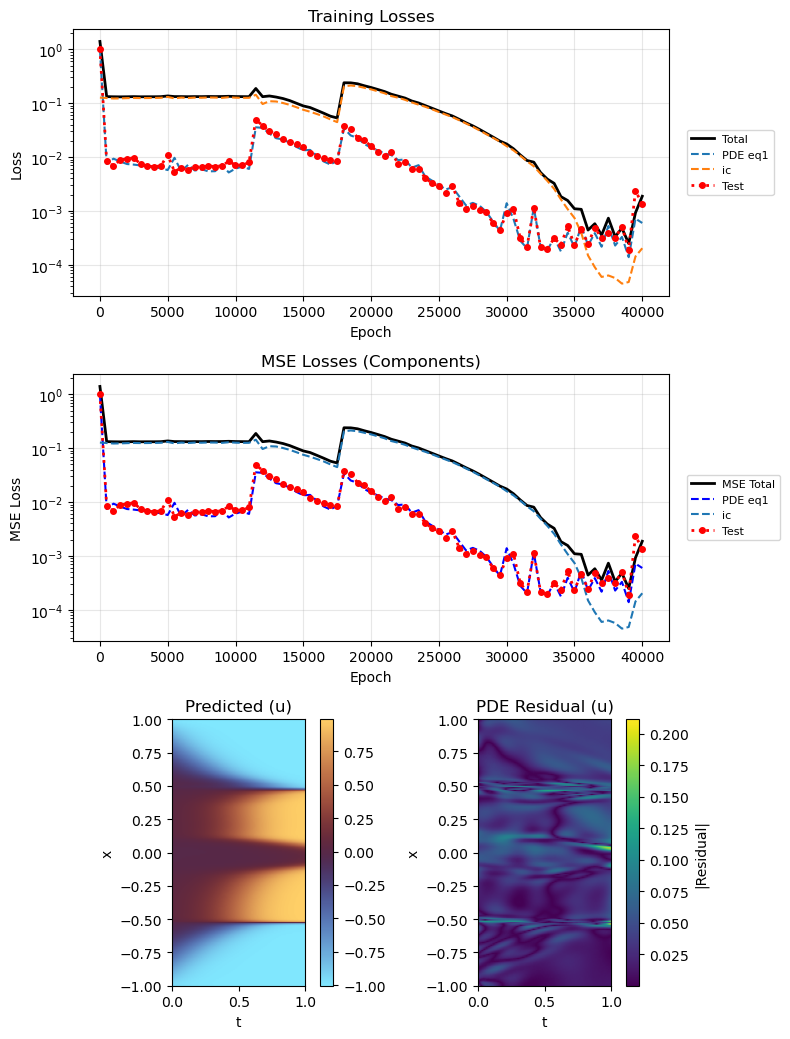

Starting Trainer (JAX, Lagrangian mode) for 40000 epochs...
Epoch 0/40000 | MSE Loss: 1.40e+00 | PDE: 9.96e-01 | BCs: [ic: 1.27e-01]
Epoch 500/40000 | AL Loss: 1.45e-01 | MSE Loss: 1.32e-01 | PDE: 7.47e-03 | BCs: [ic: 1.25e-01] | Time: 3.1s
Epoch 1000/40000 | AL Loss: 1.56e-01 | MSE Loss: 1.31e-01 | PDE: 9.33e-03 | BCs: [ic: 1.22e-01] | Time: 4.1s
Epoch 1500/40000 | AL Loss: 1.67e-01 | MSE Loss: 1.31e-01 | PDE: 8.25e-03 | BCs: [ic: 1.23e-01] | Time: 5.2s
Epoch 2000/40000 | AL Loss: 1.80e-01 | MSE Loss: 1.31e-01 | PDE: 7.41e-03 | BCs: [ic: 1.24e-01] | Time: 6.3s
Epoch 2500/40000 | AL Loss: 1.93e-01 | MSE Loss: 1.32e-01 | PDE: 7.23e-03 | BCs: [ic: 1.25e-01] | Time: 7.4s
Epoch 3000/40000 | AL Loss: 2.04e-01 | MSE Loss: 1.31e-01 | PDE: 6.98e-03 | BCs: [ic: 1.24e-01] | Time: 8.5s
Epoch 3500/40000 | AL Loss: 2.16e-01 | MSE Loss: 1.32e-01 | PDE: 6.96e-03 | BCs: [ic: 1.25e-01] | Time: 9.6s
Epoch 4000/40000 | AL Loss: 2.28e-01 | MSE Loss: 1.32e-01 | PDE: 6.48e-03 | BCs: [ic: 1.25e-01] | Time: 1

In [16]:
trainer = pinns.Trainer(problem, network)

trainer.compile(
    train_samples={
        "pde": 5000,
        "ic":  200,
        # periodic BC: no entry needed — pairs are sampled automatically
    },
    test_samples={
        "pde": 2000,
        "ic":  0,
    },
    weights={
        "pde":      1.0,
        "ic":       1.0,
        "periodic": 1.0,   # soft periodicity penalty (u and u_x)
    },
    optimizer="adam",
    learning_rate=1e-3,
    lagrange_lr=1e-4,
    epochs=40_000,
    print_each=500,
    show_plots=True,
)

trainer.train()
